In [1]:
import sys
import os
sys.path.append("../intervention_search")

import covasim as cv

from simulation.runner import run_evo_simulation

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM


In [2]:
sim_pars = dict(
    pop_size=3000,
    pop_type='hybrid',
    pop_infected=5,
    n_days=60,
    rand_seed=1,
    beta=0.1, 
    verbose=0,    
)

evo_pars = dict(
  enable=True,
  reference="/home/jhkim/covasim_project/covasim4wastewater/docs/tutorials/sars-2-data/NC_045512_Hu-1.fasta",
  mol_clock_rate=0.0001,
  sub_model="JC",
  fitness_data_path="/home/jhkim/covasim_project/covasim4wastewater/data/nt_fitness.csv",
  store_infection_log=True,
) 

policy = dict(
    p_test=0.3,
    p_seq=0.5,
    detection_threshold=3,
    delay_pmf=[0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03],
    quiet_period=0,
)

In [3]:
sim, obs, interv, _, results = run_evo_simulation(sim_pars, evo_pars, policy)

In [4]:
cum = int(sim.results['new_infections'].values.sum())

print(cum)

225


In [5]:
from analysis.mutation_tree import build_mutation_tree, build_infection_seq_tree, mutation_tree_to_newick, extract_sequenced_subtree, export_fasta_from_G, infer_tree_jc69, add_internal_leaves, set_all_branch_lengths_to_one
from plotting.plot_mutation_tree import plot_mutation_tree, plot_erase_mutation_tree, plot_phylo_tree

In [6]:
FIG_DIR = "../intervention_search/results/figures"

Policy B mutation tree: nodes=231, edges=230


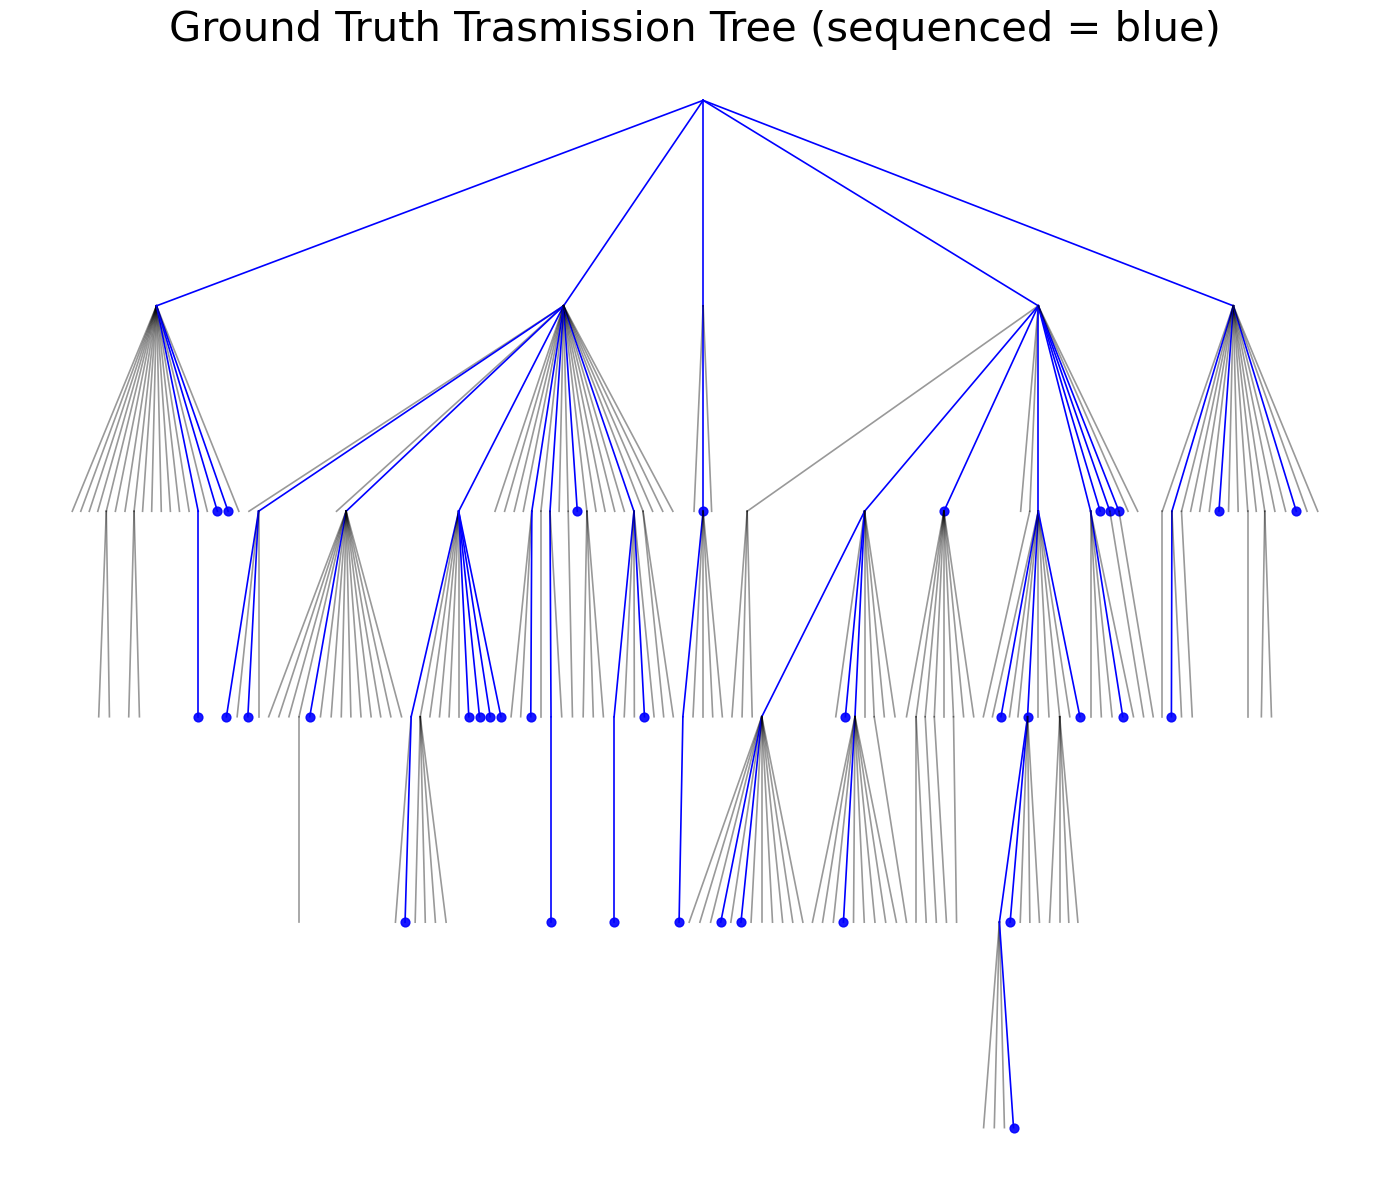

Policy B mutation tree: nodes=226, edges=225


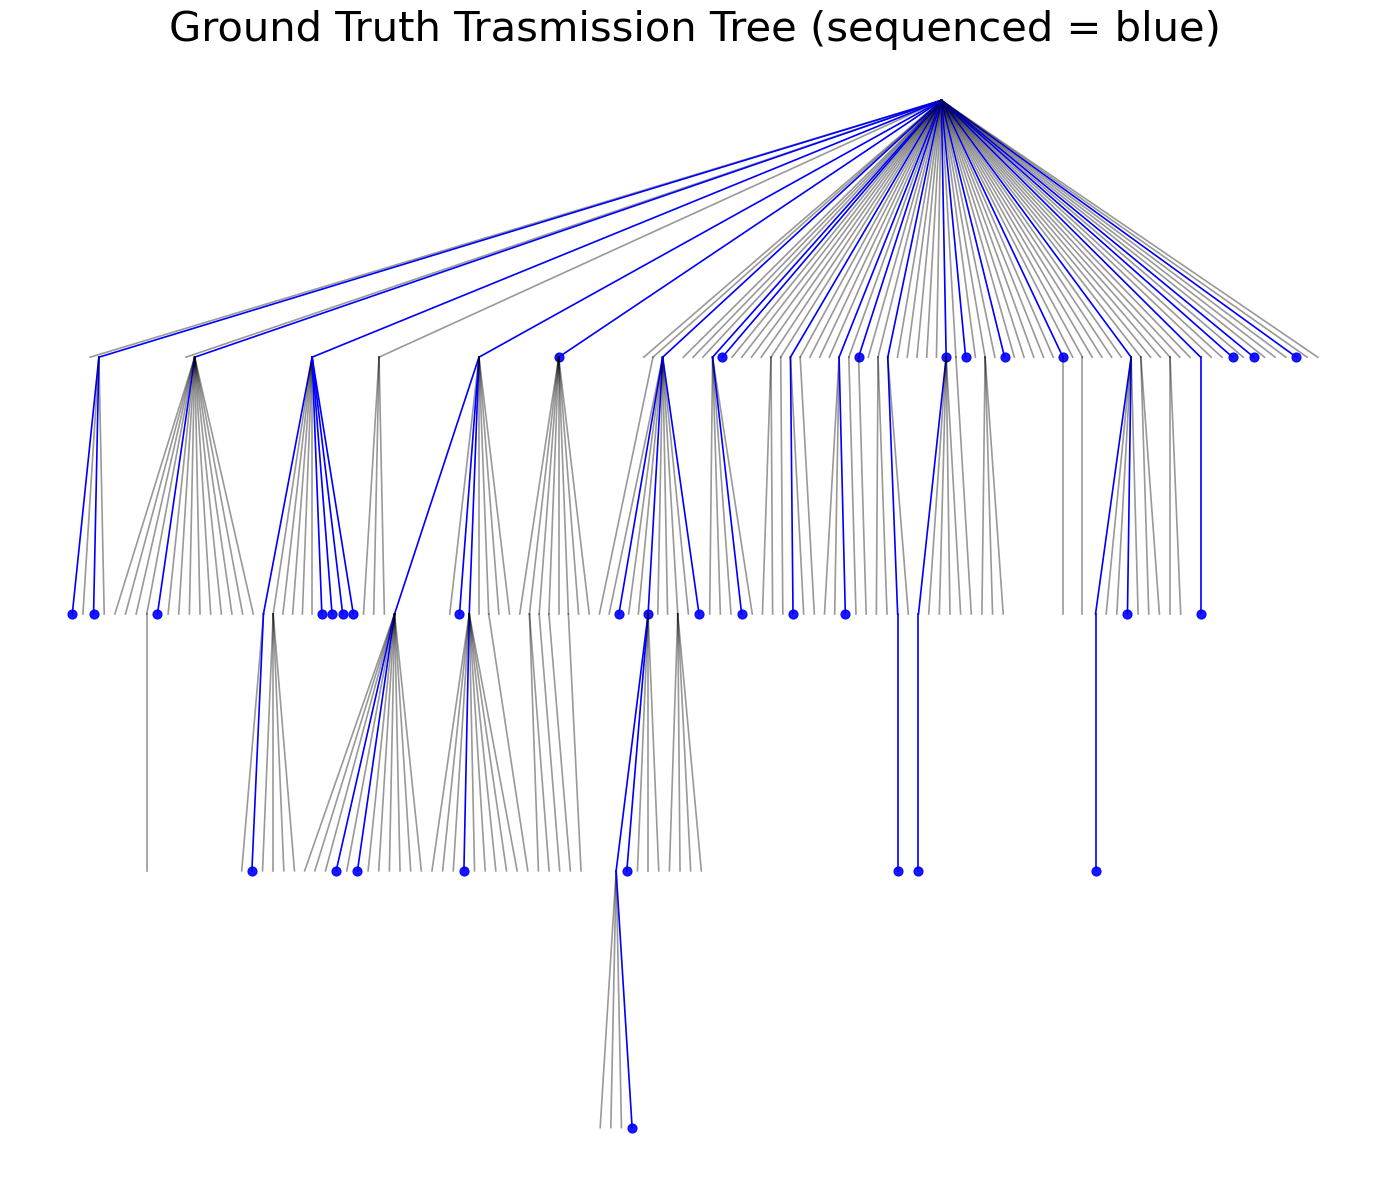

Policy B mutation tree: nodes=54, edges=53


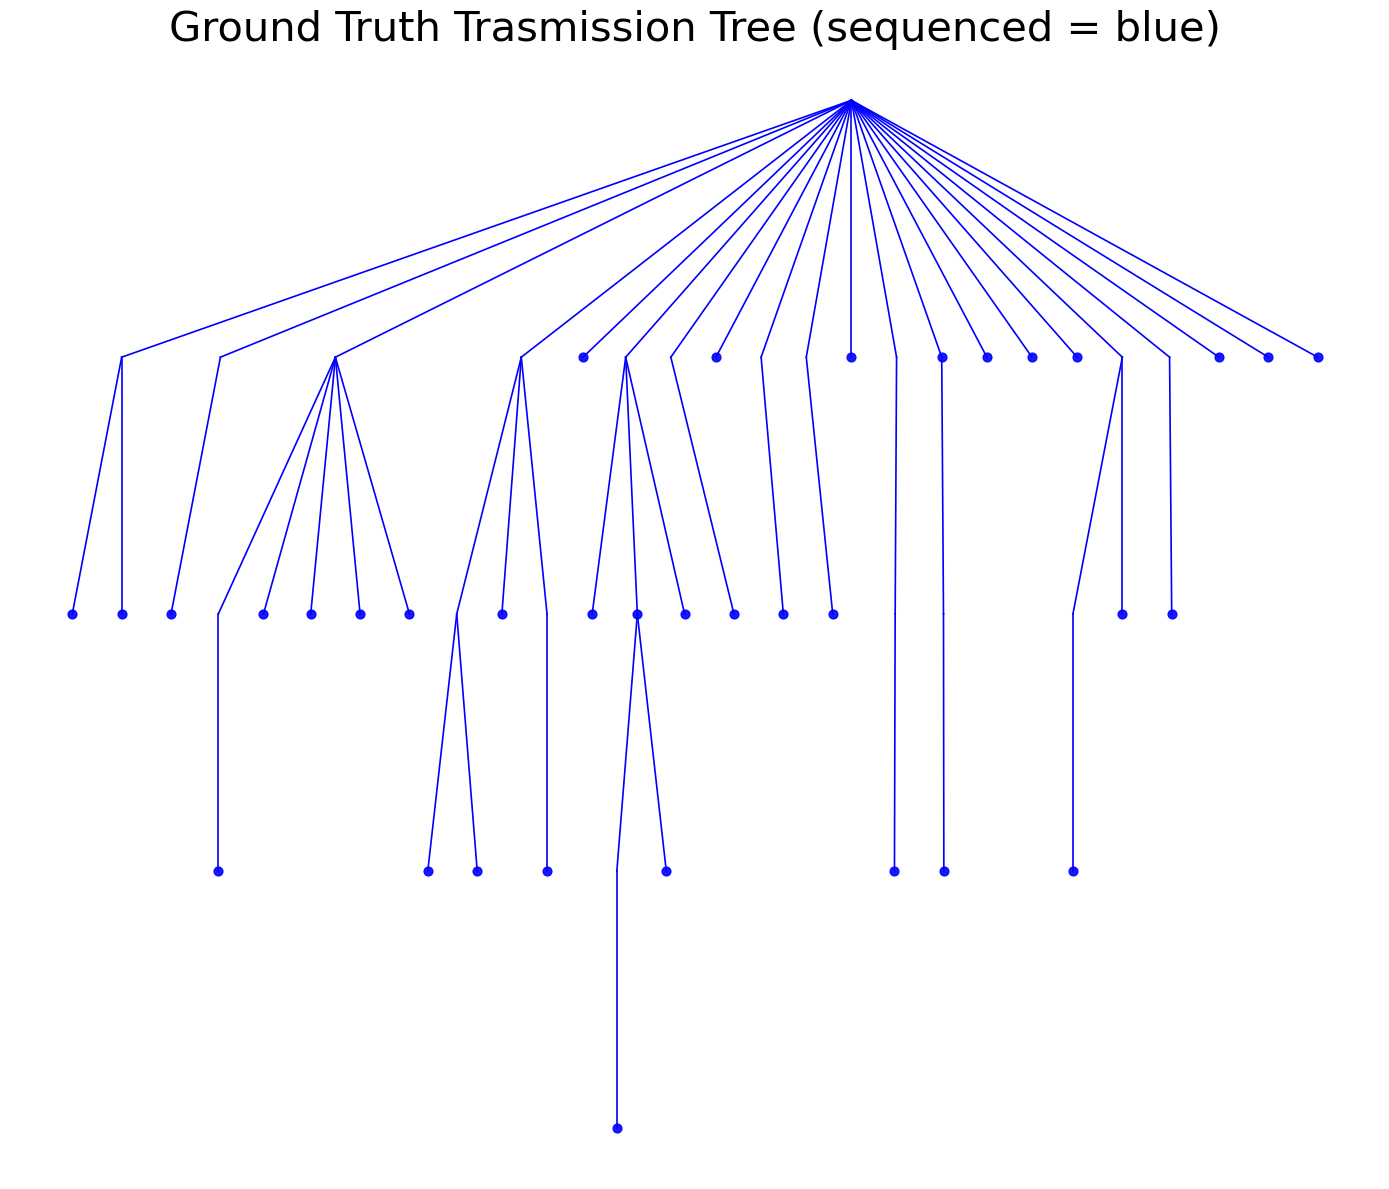

In [7]:
sequenced_agents = set()
for day_list in obs.daily_sequenced_agents:
    sequenced_agents.update(day_list)

G = build_mutation_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G.nodes)}, edges={len(G.edges)}")

plot_erase_mutation_tree(
    G,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policy_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

G_infect, mutation_nodes, node_events = build_infection_seq_tree(sim, daily_sequenced_agents=obs.daily_sequenced_agents)
print(f"Policy B mutation tree: nodes={len(G_infect.nodes)}, edges={len(G_infect.edges)}")

plot_erase_mutation_tree(
    G_infect,
    savepath=os.path.join(FIG_DIR, "mutation_tree_policy_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

G_prune = extract_sequenced_subtree(G_infect)
print(f"Policy B mutation tree: nodes={len(G_prune.nodes)}, edges={len(G_prune.edges)}")

plot_erase_mutation_tree(
    G_prune,
    savepath=os.path.join(FIG_DIR, "mutation_tree_prune_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

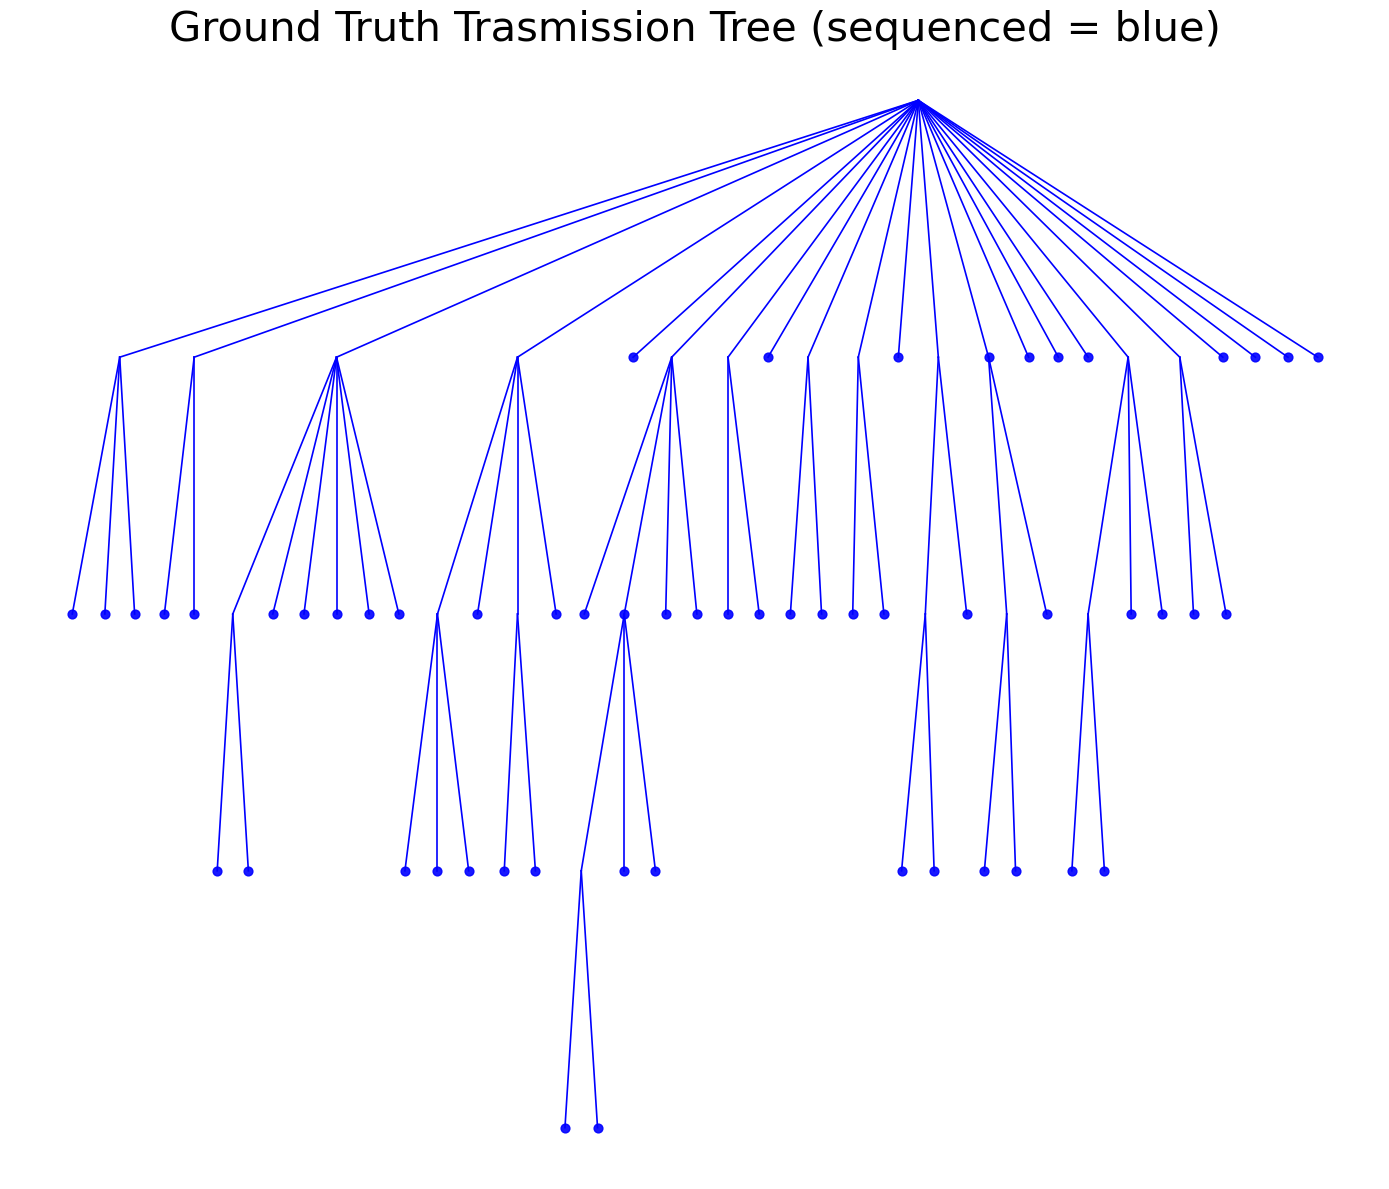

In [8]:
G_prune_leaf = add_internal_leaves(G_prune)
plot_erase_mutation_tree(
    G_prune_leaf,
    savepath=os.path.join(FIG_DIR, "mutation_tree_prune_seq.png"),
    show=True,
    detection_day=None,
    erase=False,          # True = edge -> delete, False = edge -> transparent
    sequenced_only=False,
    collapse=False,
)

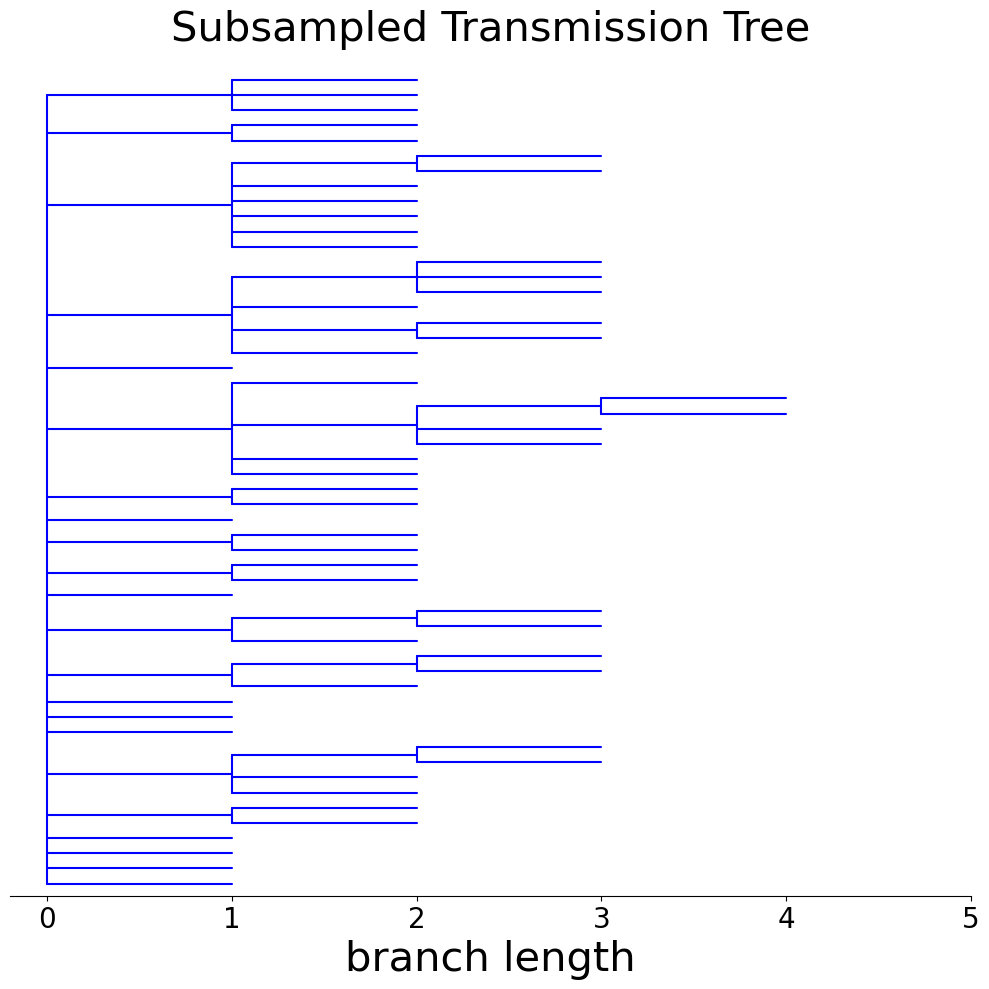

In [9]:
newick_str = mutation_tree_to_newick(G_prune_leaf)

from io import StringIO
from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read(StringIO(newick_str), "newick")

fig = plt.figure(figsize=(10, 10))  
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree, 
    do_show=False, 
    axes=ax,
    label_func=lambda x: None
)    

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.tick_params(axis='x', labelsize=20)
ax.get_yaxis().set_visible(False)

for coll in ax.collections:
    coll.set_color("blue")
    

plt.title("Subsampled Transmission Tree", fontsize=30, pad=20)
plt.tight_layout()

plt.show()

IQ-TREE version 3.1.2 for Linux x86 64-bit built May 17 2026
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Host:    localhost (AVX2, FMA3, 7 GB RAM)
Command: iqtree -s polytomy_test.fasta -m JC69 -czb
Seed:    205750 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Wed Aug  5 16:38:55 2026
Kernel:  AVX+FMA - 1 threads (18 CPU cores detected)

HINT: Use -nt option to specify number of threads because your CPU has 18 cores!
HINT: -nt AUTO will automatically determine the best number of threads to use.

Reading alignment file polytomy_test.fasta ... Fasta format detected
Reading fasta file: done in 0.0132661 secs using 105.9% CPU
Alignment most likely contains DNA/RNA sequences
Constructing alignment: done in 0.01671 secs using 105.9% CPU
Alignment has 54 sequences with 29903 columns, 474 distinct patterns
273 parsimony-i

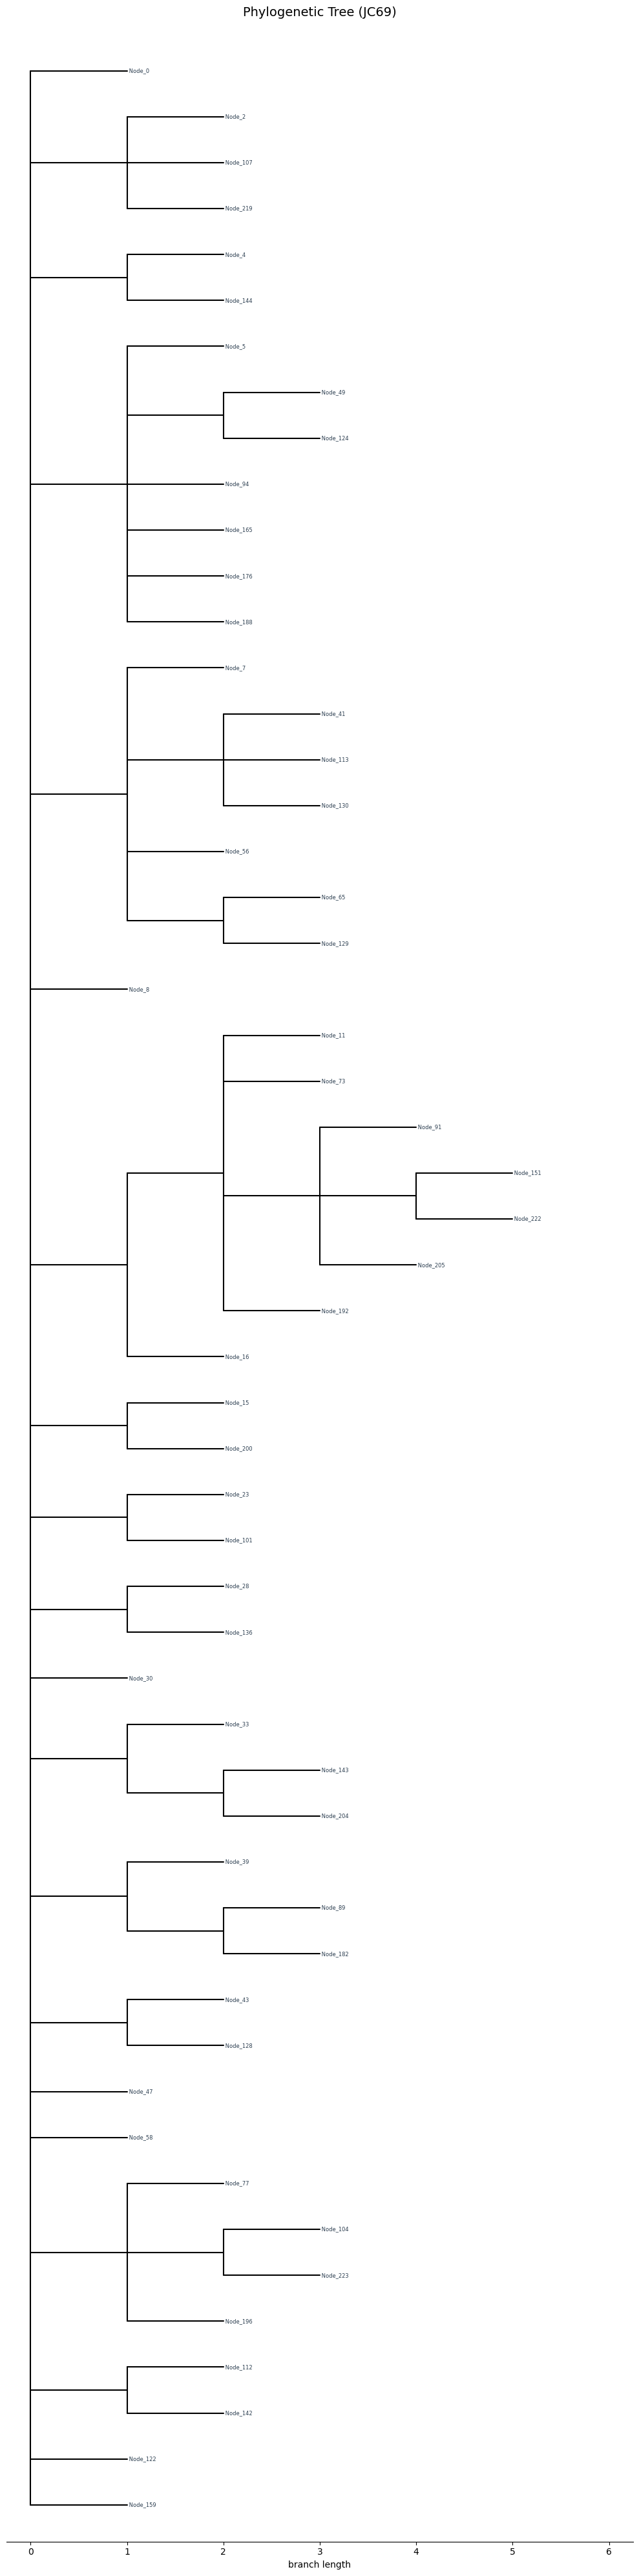

In [10]:
fasta_path = "polytomy_test.fasta"
export_fasta_from_G(G_prune, sim, fasta_path)

newick_path = infer_tree_jc69(fasta_path)

newick_bl1_path = set_all_branch_lengths_to_one(newick_path)

plot_phylo_tree(newick_bl1_path, savepath=None)

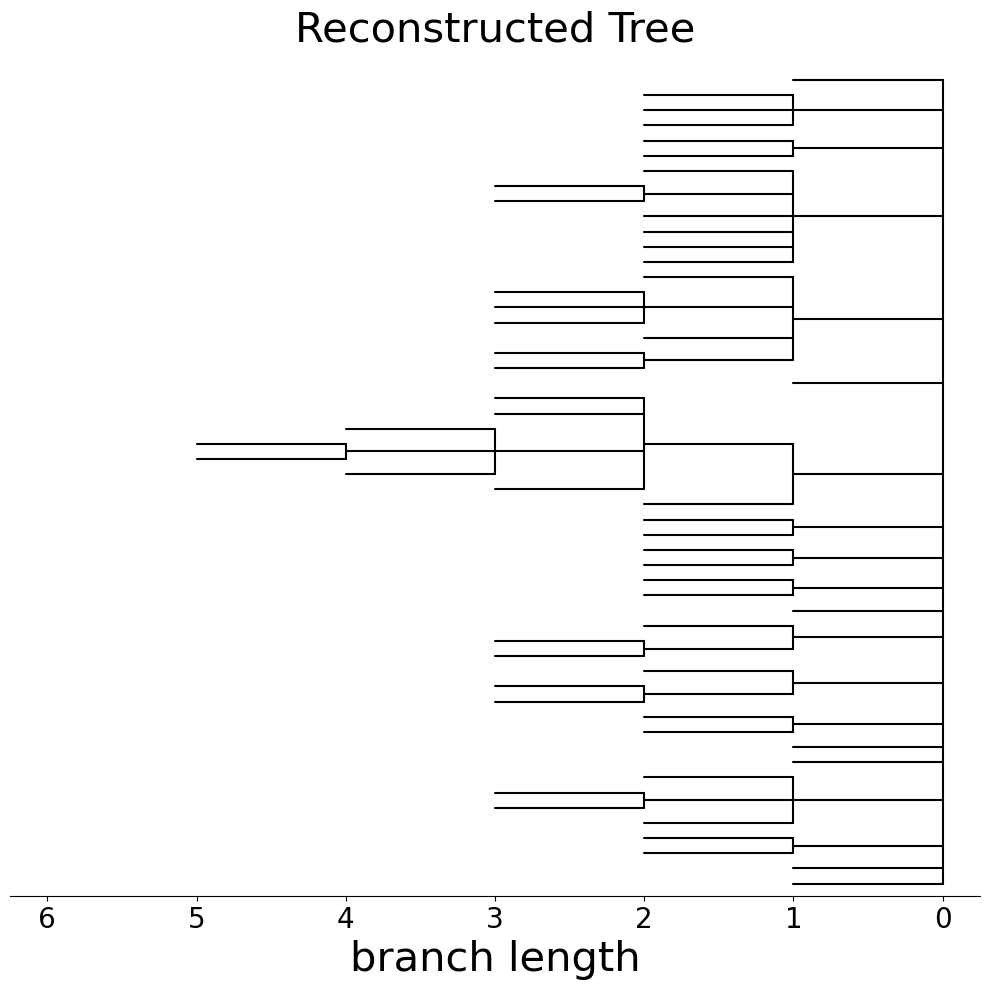

In [11]:
newick_path = "/home/jhkim/covasim_project/jhk_covasim4wastewater/weekly_reports/polytomy_test.fasta.treefile"

newick_bl1_path = set_all_branch_lengths_to_one(newick_path)

tree = Phylo.read(newick_bl1_path, "newick")

fig = plt.figure(figsize=(10, 10))  
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree, 
    do_show=False, 
    axes=ax,
    label_func=lambda x: None
)
ax.invert_xaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xlabel(ax.get_xlabel(), fontsize=30)
ax.tick_params(axis='x', labelsize=20)
ax.get_yaxis().set_visible(False)

plt.title("Reconstructed Tree", fontsize=30, pad=20)
plt.tight_layout()
plt.show()


INFO  : Finished optimising at entanglement 0.008 (tanglegram.tangle)
INFO  : Finished optimising at entanglement 0.008 (tanglegram.tangle)
INFO  : Done. Use matplotlib.pyplot.show() to show plot. (tanglegram.tangle)


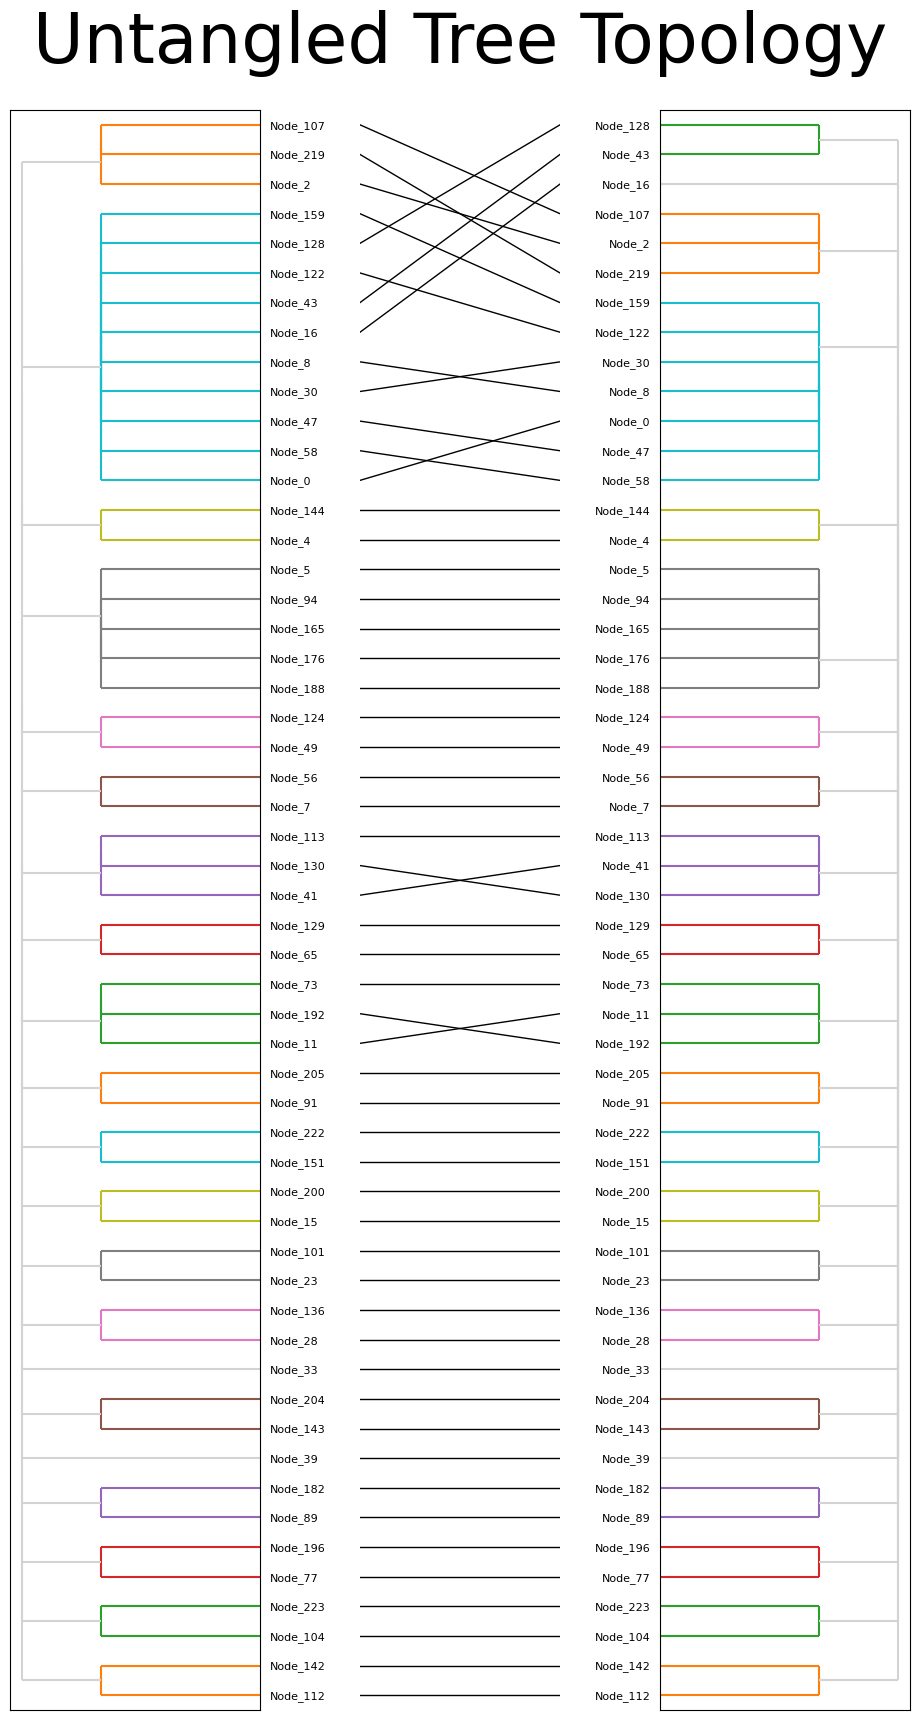

Entanglement: 0.0076128345344189784
Crossings: 20
Alignment quality: Alignment quality (54 leafs, 54 edges)
  entanglement           0.0076   (random layout: 0.5520 +/- 0.1161, z = -4.7)
  crossings                  20
  better than random       99%
  displacement       median 0, max 5 slots; 89% of edges within 2
  verdict            re-optimising reached 0.0071; try more restarts


In [12]:
from cophylogeny.tanglegram import plot_tanglegram

plot_tanglegram(newick_str, newick_bl1_path)

crossings before: 107
crossings after:  0


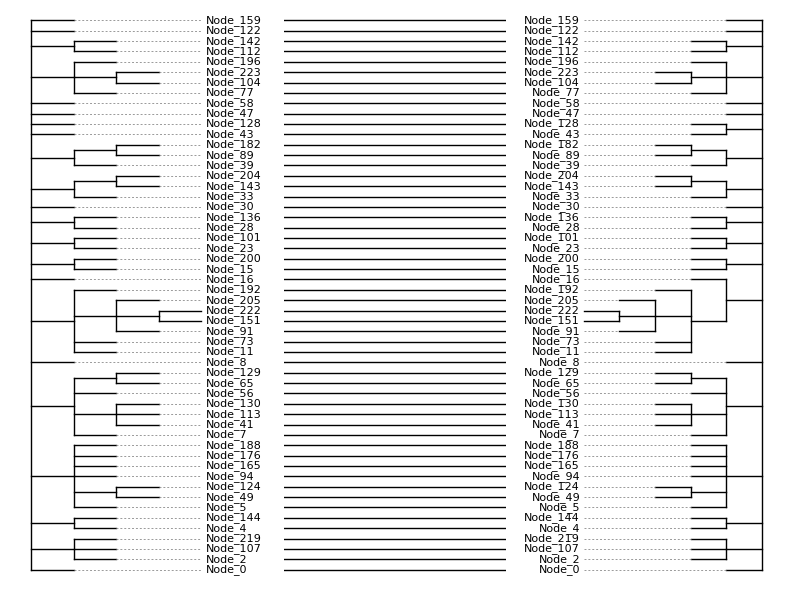

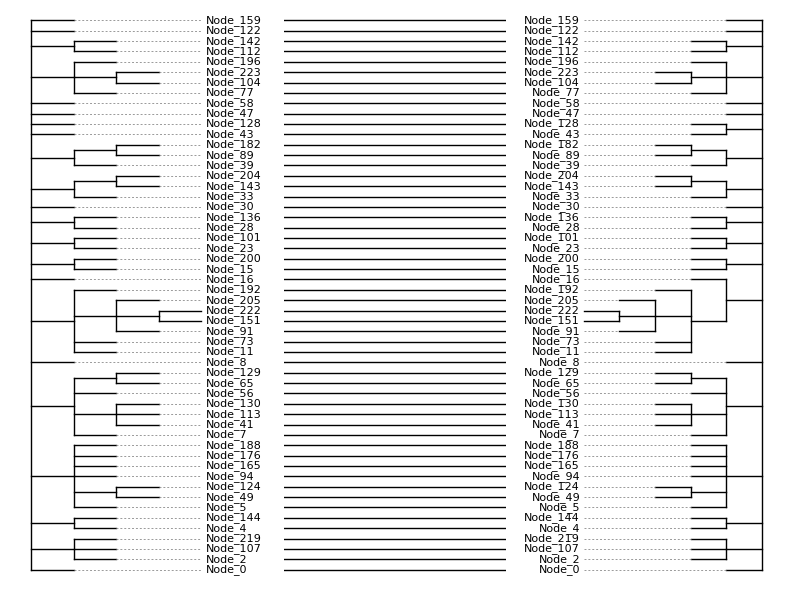

In [13]:
from cophylogeny.polytomy_tanglegram import run_polytomy_tanglegram

run_polytomy_tanglegram(newick_str, newick_bl1_path)